In [67]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

In [68]:
df = pd.read_pickle("cleaned_online_retail.pkl")
print(df.shape)
df.head()

(406309, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# **STEP 3 : FEATURE ENGINEERING**

In [69]:
# adding a new feature as 'Sales'
df['Sales'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [70]:
# creating a new df with unique coustomer id
unique_df = df.groupby(by="Customer ID", as_index=False).agg(
        TotalSale = ("Sales", "sum"),
        Frequency = ("Invoice", "nunique"),
        LastInvoiceDate = ("InvoiceDate", "max")
    )


# as_index = False means we dont want to make customer id as index

unique_df.head()

,Customer ID,TotalSale,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [71]:
unique_df.describe()

,Customer ID,TotalSale,Frequency,LastInvoiceDate
count,4285.000000,4285.000000,4285.000000,4285
mean,15356.806768,2024.126801,4.426138,2010-09-11 00:06:10.431738624
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00
25%,13891.000000,307.560000,1.000000,2010-07-27 14:39:00
50%,15362.000000,702.900000,2.000000,2010-10-19 12:10:00
75%,16840.000000,1704.290000,5.000000,2010-11-22 11:24:00
max,18287.000000,349164.350000,183.000000,2010-12-09 20:01:00
std,1699.839258,8813.945538,7.938017,NaN


In [ ]:
# finding day and month from the newest date in the data

oldest_invoice_date = unique_df['LastInvoiceDate'].max()

print("OLDERST DATE : ", oldest_invoice_date)
print()

delta = oldest_invoice_date - unique_df['LastInvoiceDate']

# 1. Total Days
unique_df['RecencyInDays'] = delta.dt.days

# 2. Total Months (Approximate: 30.44 days per month)
unique_df['RecencyInMonths'] = delta.dt.days / 30.44

# 3. Total Years (Approximate: 365.25 days per year)
# unique_df['RecencyInYears'] = delta.dt.days / 365.25

# print(unique_df['RecencyInYears'].max())

unique_df.head()


OLDERST DATE :  2010-12-09 20:01:00



,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.387648
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0.065703
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2.398160
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1.379763
4,12351.0,300.93,1,2010-11-29 15:23:00,10,0.328515


In [76]:
# finding the days and months of the data based on todays date

today = pd.to_datetime('today')

unique_df['RecencyInDays'] = (today - unique_df['LastInvoiceDate']).dt.days
unique_df['RecencyInMonths'] = ((today - unique_df['LastInvoiceDate']).dt.days / 30.44).astype(int)
unique_df['RecencyInYears'] = ((today - unique_df['LastInvoiceDate']).dt.days / 365.25).astype(int)

unique_df.head(10)

,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears
0,12346.0,169.36,2,2010-06-28 13:53:00,5709,187,15
1,12347.0,1323.32,2,2010-12-07 14:57:00,5547,182,15
2,12348.0,221.16,1,2010-09-27 14:59:00,5618,184,15
3,12349.0,2221.14,2,2010-10-28 08:23:00,5588,183,15
4,12351.0,300.93,1,2010-11-29 15:23:00,5555,182,15
5,12352.0,343.80,2,2010-11-29 10:07:00,5556,182,15
6,12353.0,317.76,1,2010-10-27 12:44:00,5589,183,15
7,12355.0,488.21,1,2010-05-21 11:59:00,5748,188,15
8,12356.0,3126.25,3,2010-11-24 12:24:00,5561,182,15
9,12357.0,11229.99,1,2010-11-16 10:05:00,5569,182,15


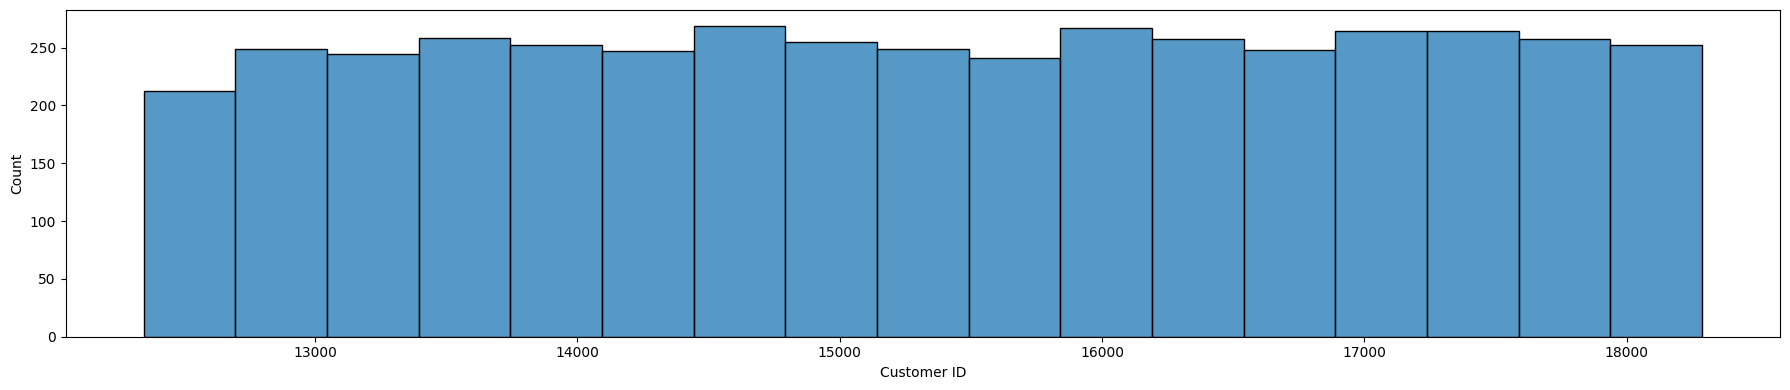

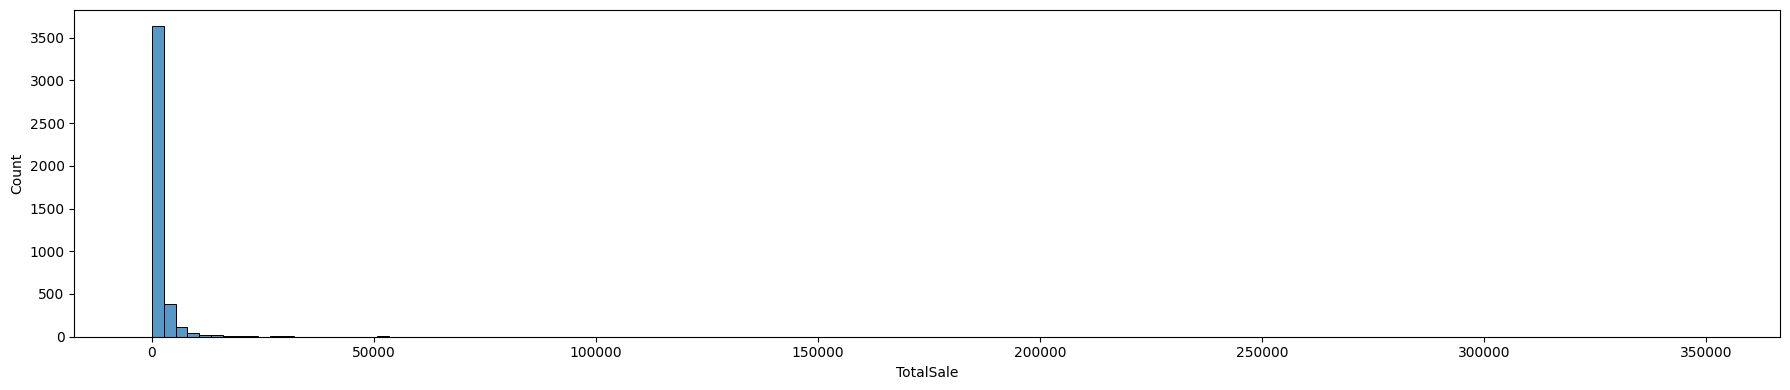

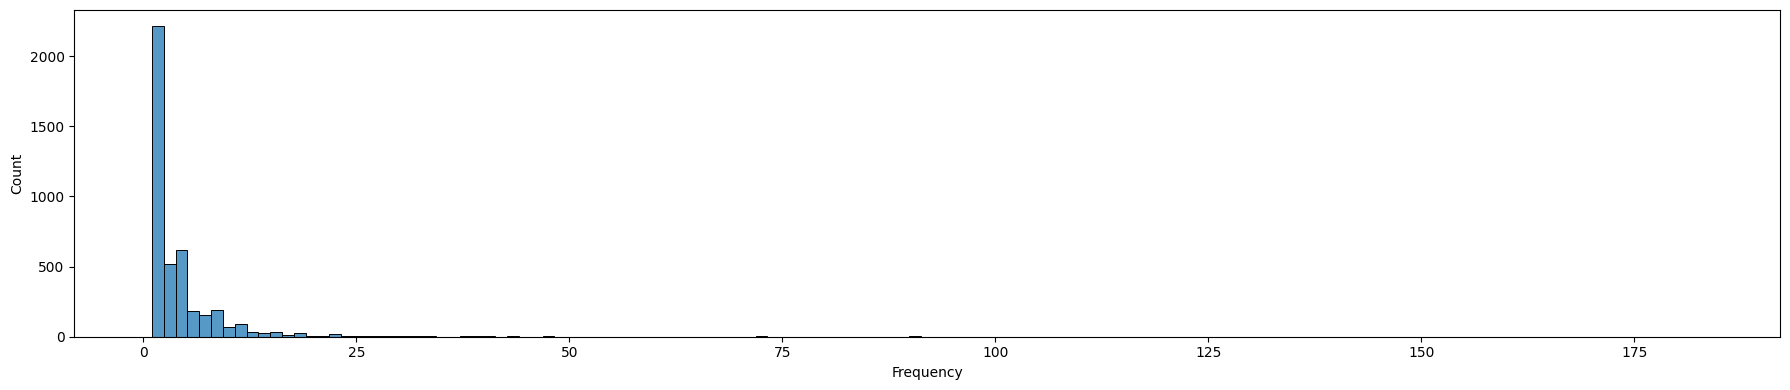

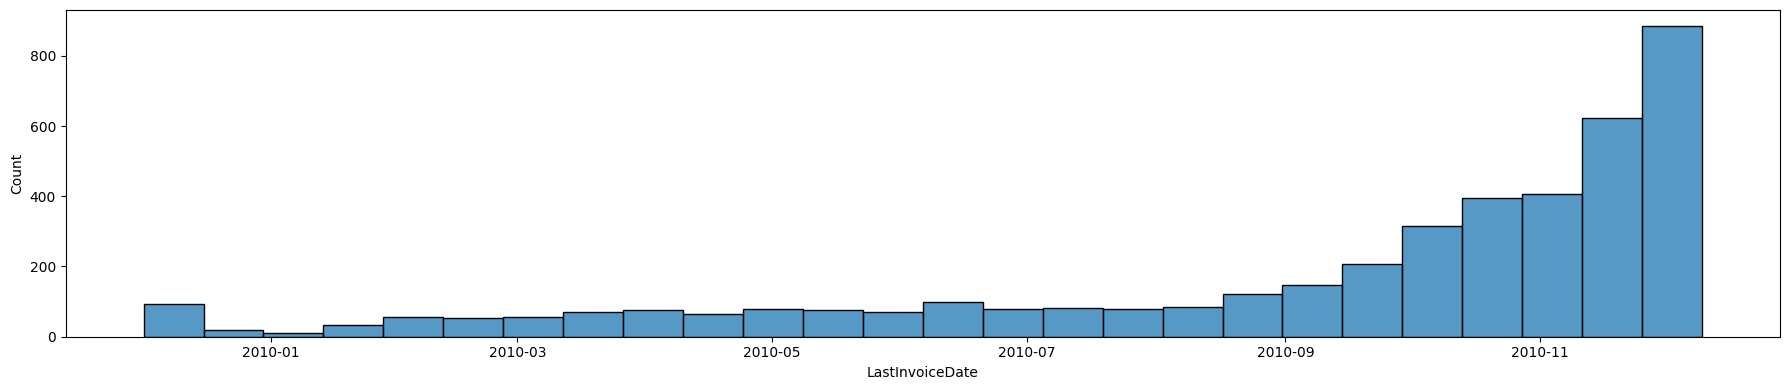

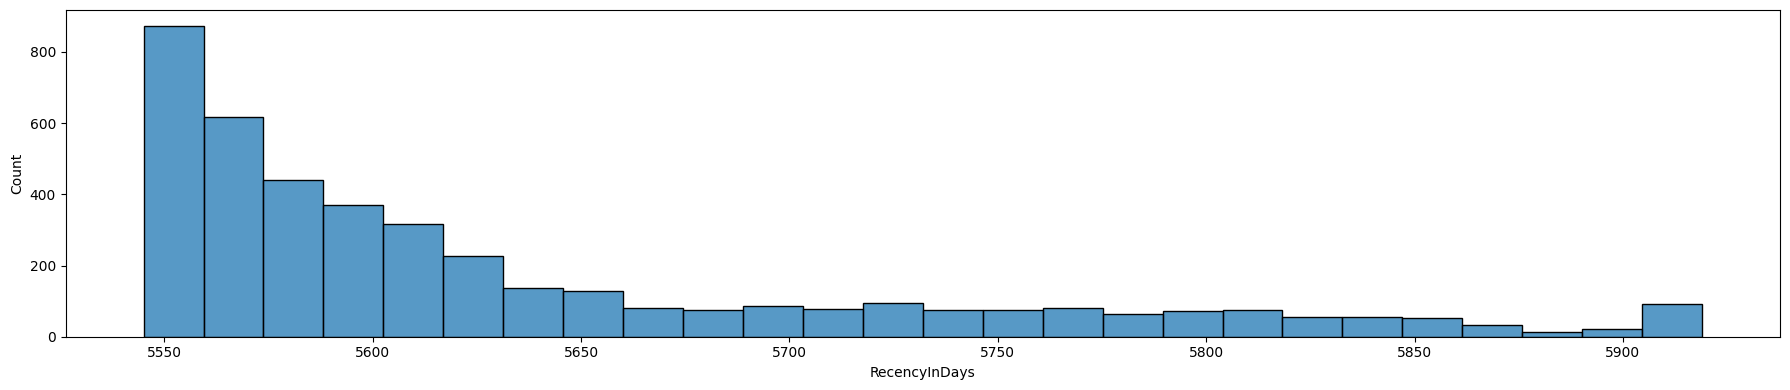

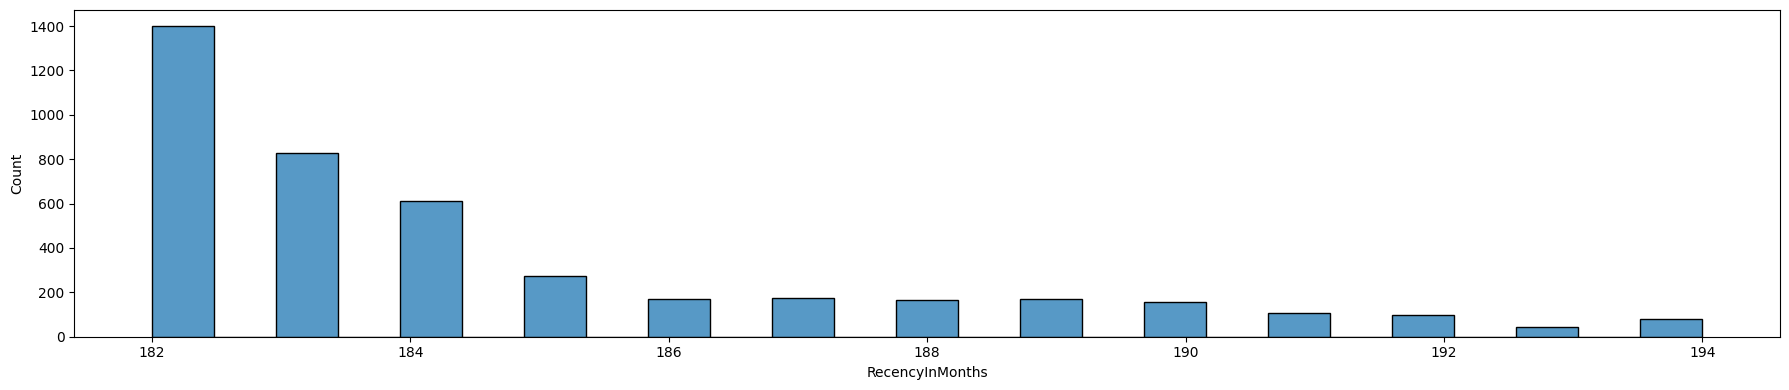

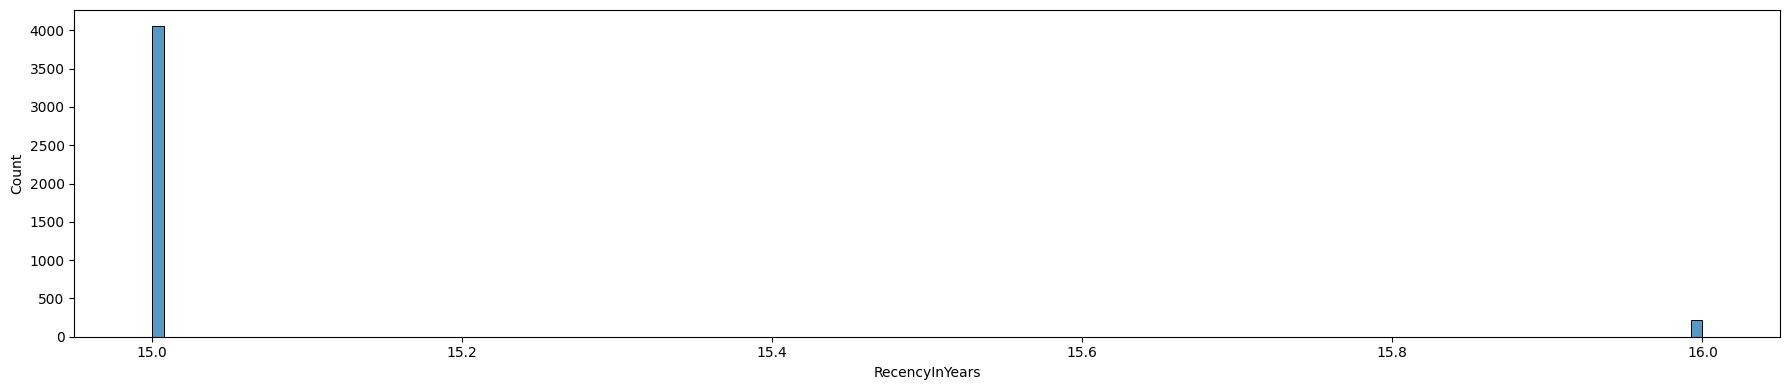

In [ ]:
# plotting the data

for i in unique_df.columns:
    
    plt.figure(figsize=(18,4))
    sns.histplot(unique_df[i])
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

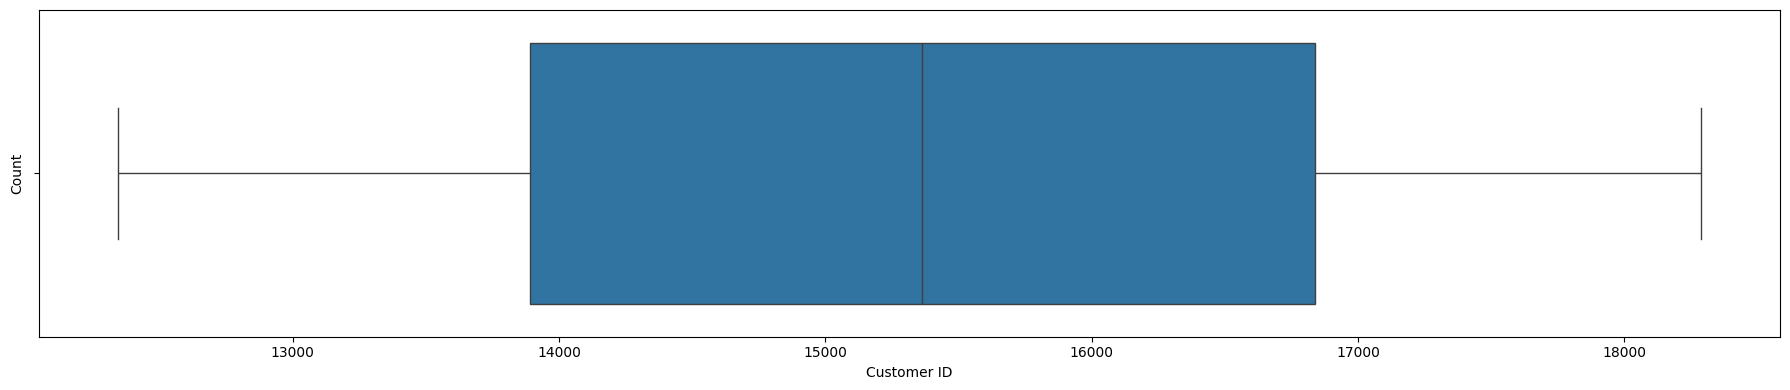

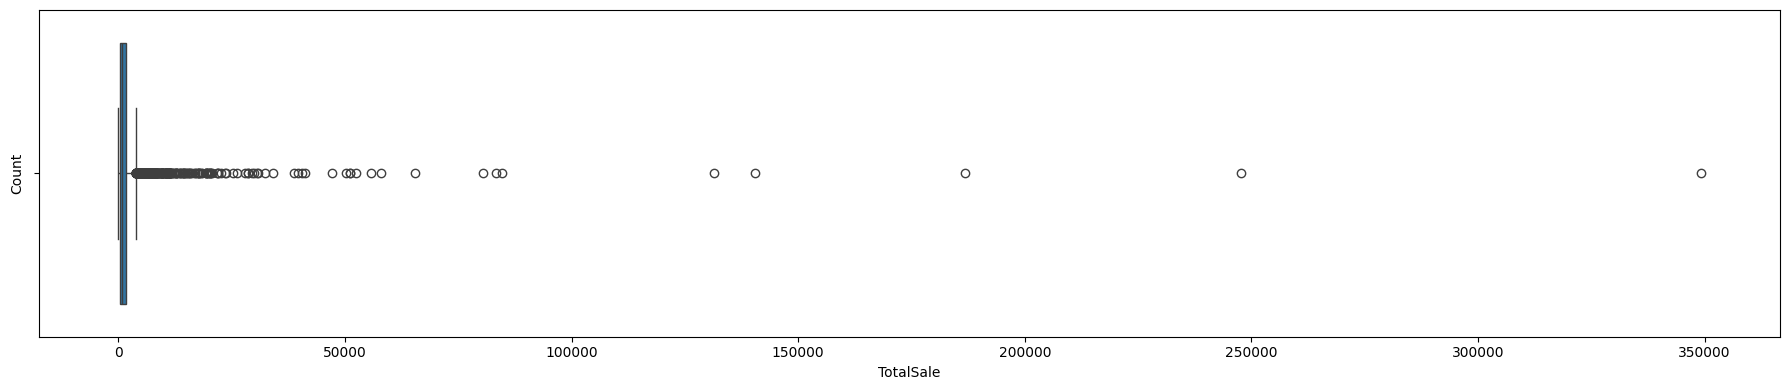

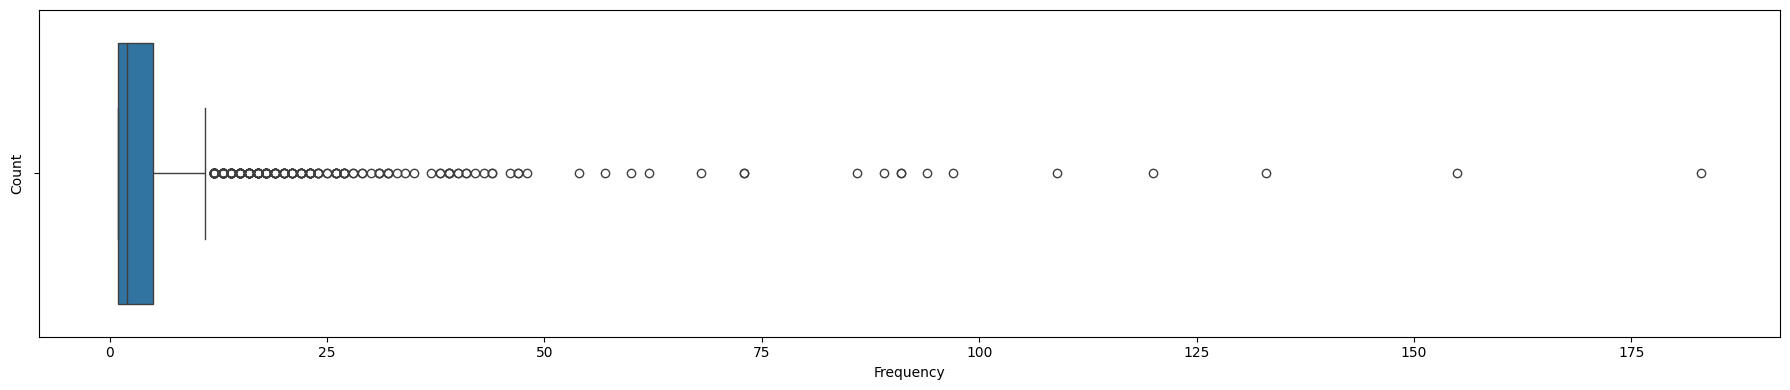

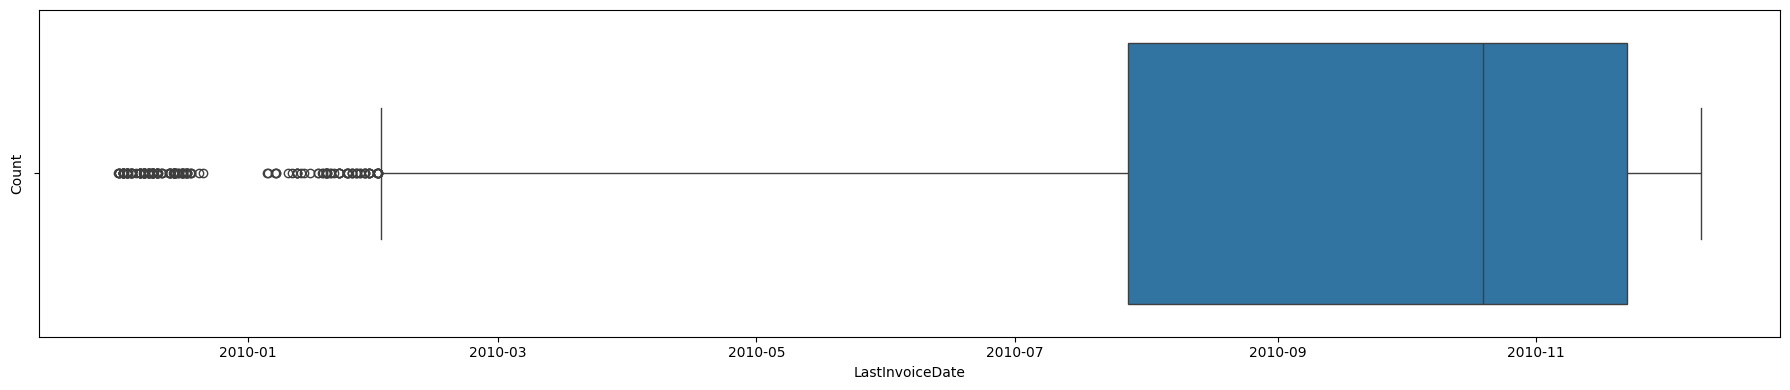

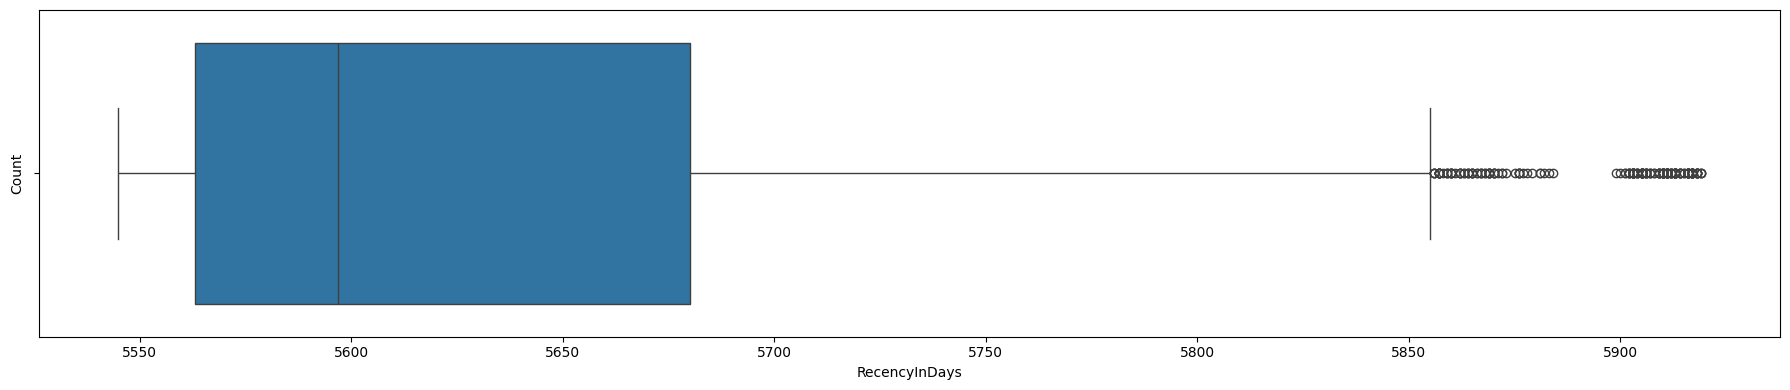

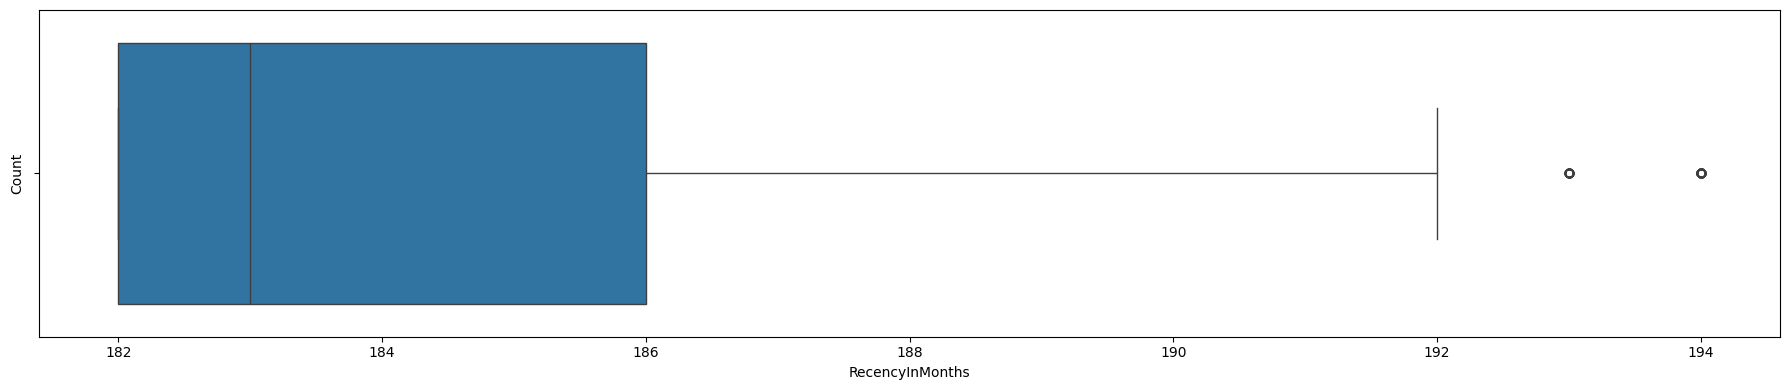

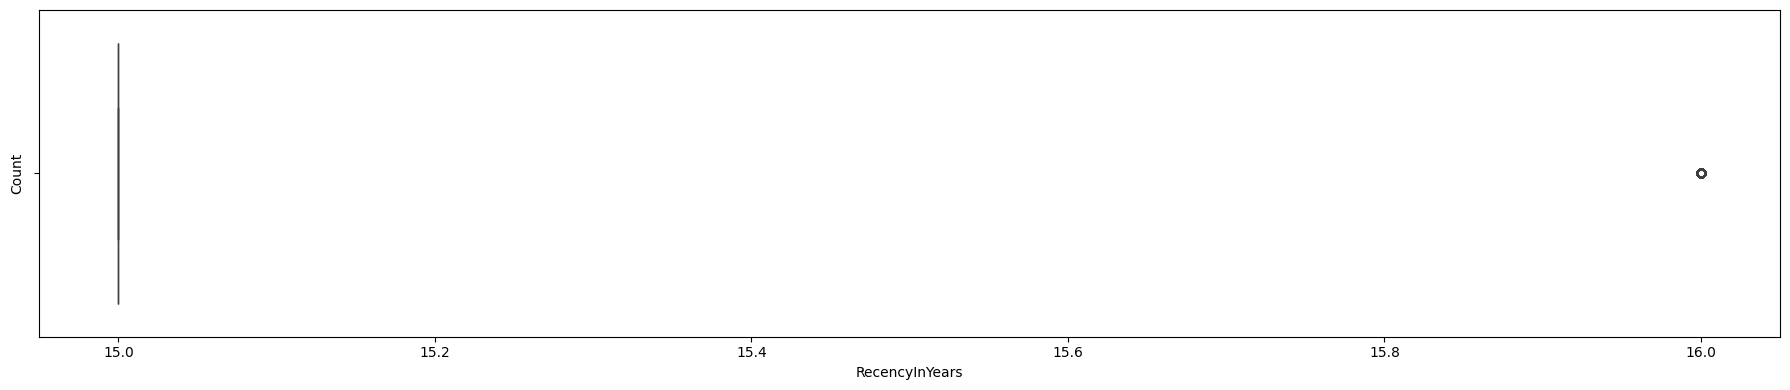

In [83]:
for i in unique_df.columns:
    
    plt.figure(figsize=(18,4))
    sns.boxplot(x=unique_df[i])
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()